# Customer Churn Prediction using Logistic Regression

**Goal:** Predict whether a telecom customer will churn (leave) based on their usage patterns.

**Dataset:** Telecom Churn dataset (BigML)
- Training set: ~2666 rows
- Test set: ~667 rows
- Target column: `Churn` (True / False)

**Why Logistic Regression?**
Even though the name says 'regression', Logistic Regression is a classification algorithm.
It predicts the *probability* that a customer will churn, which makes it easy to interpret.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Data

The dataset is already split into train (80%) and test (20%) sets.

In [2]:
# Load training and test data
train_df = pd.read_csv('churn-bigml-80.csv')
test_df  = pd.read_csv('churn-bigml-20.csv')

print(f'Training set shape : {train_df.shape}')   # rows x columns
print(f'Test set shape     : {test_df.shape}')
print()
print('First 5 rows of training data:')
train_df.head()

Training set shape : (2666, 20)
Test set shape     : (667, 20)

First 5 rows of training data:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## Step 3: Explore the Data (EDA)

Before building a model, always understand your data.

In [3]:
# Check column data types and missing values
print('Column info:')
train_df.info()

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
State                     2666 non-null object
Account length            2666 non-null int64
Area code                 2666 non-null int64
International plan        2666 non-null object
Voice mail plan           2666 non-null object
Number vmail messages     2666 non-null int64
Total day minutes         2666 non-null float64
Total day calls           2666 non-null int64
Total day charge          2666 non-null float64
Total eve minutes         2666 non-null float64
Total eve calls           2666 non-null int64
Total eve charge          2666 non-null float64
Total night minutes       2666 non-null float64
Total night calls         2666 non-null int64
Total night charge        2666 non-null float64
Total intl minutes        2666 non-null float64
Total intl calls          2666 non-null int64
Total intl charge         2666 non-null float64
Customer service calls    2666 no

In [4]:
# Check for missing values
print('Missing values per column:')
print(train_df.isnull().sum())
print()
print('No missing values means we can proceed without imputation!')

Missing values per column:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

No missing values means we can proceed without imputation!


Churn distribution in training data:
False    2278
True      388
Name: Churn, dtype: int64

Churn rate: 14.6%


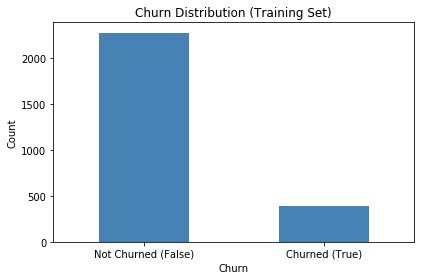

In [5]:
# Check the target variable distribution
# This tells us how many customers actually churned vs stayed
churn_counts = train_df['Churn'].value_counts()
print('Churn distribution in training data:')
print(churn_counts)
print()
print(f'Churn rate: {churn_counts[True] / len(train_df) * 100:.1f}%')

# Plot it
fig, ax = plt.subplots(figsize=(6, 4))
churn_counts.plot(kind='bar', color=['steelblue', 'tomato'], ax=ax)
ax.set_title('Churn Distribution (Training Set)')
ax.set_xlabel('Churn')
ax.set_ylabel('Count')
ax.set_xticklabels(['Not Churned (False)', 'Churned (True)'], rotation=0)
plt.tight_layout()
plt.show()

In [6]:
# Basic statistics for numeric columns
train_df.describe().round(2)

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00,2666.00
mean,100.62,437.44,8.02,179.48,100.31,30.51,200.39,100.02,17.03,201.17,100.11,9.05,10.24,4.47,2.76,1.56
std,39.56,42.52,13.61,54.21,19.99,9.22,50.95,20.16,4.33,50.78,19.42,2.29,2.79,2.46,0.75,1.31
min,1.00,408.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,43.70,33.00,1.97,0.00,0.00,0.00,0.00
25%,73.00,408.00,0.00,143.40,87.00,24.38,165.30,87.00,14.05,166.92,87.00,7.51,8.50,3.00,2.30,1.00
50%,100.00,415.00,0.00,179.95,101.00,30.59,200.90,100.00,17.08,201.15,100.00,9.05,10.20,4.00,2.75,1.00
75%,127.00,510.00,19.00,215.90,114.00,36.70,235.10,114.00,19.98,236.48,113.00,10.64,12.10,6.00,3.27,2.00
max,243.00,510.00,50.00,350.80,160.00,59.64,363.70,170.00,30.91,395.00,166.00,17.77,20.00,20.00,5.40,9.00


## Step 4: Preprocessing

Logistic Regression requires:
1. All features to be **numeric** (no text like 'Yes'/'No')
2. Features to be on a **similar scale** (StandardScaler handles this)

In [12]:
# Identify categorical columns (text columns)
cat_cols = ['State', 'International plan', 'Voice mail plan']

# Drop 'State' — it has 50 unique values and won't help much
# Encode 'International plan' and 'Voice mail plan' (Yes/No → 1/0)
def preprocess(df):
    df = df.copy()
    
    # Drop State column (too many unique categories, low signal)
    df = df.drop(['State', 'Area code'],axis=1)
    
    # Encode Yes/No columns to 1/0
    df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
    df['Voice mail plan']    = df['Voice mail plan'].map({'Yes': 1, 'No': 0})
    
    # Encode target column: True → 1, False → 0
    df['Churn'] = df['Churn'].map({True: 1, False: 0})
    
    return df

# Apply to both train and test
train_clean = preprocess(train_df)
test_clean  = preprocess(test_df)

print('After preprocessing:')
train_clean.head()

After preprocessing:


,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [14]:
# Separate features (X) and target (y)
X_train = train_clean.drop(['Churn'],axis=1)
y_train = train_clean['Churn']

X_test = test_clean.drop(['Churn'],axis=1)
y_test = test_clean['Churn']

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'Features used: {list(X_train.columns)}')

X_train shape: (2666, 17)
X_test shape : (667, 17)
Features used: ['Account length', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


In [15]:
# Scale features — Logistic Regression works better when features are on the same scale
# StandardScaler makes each feature have mean=0 and std=1
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_scaled  = scaler.transform(X_test)         # only transform test (never fit on test!)

print('Scaling done!')
print(f'Mean of first feature after scaling: {X_train_scaled[:, 0].mean():.4f}  (should be ~0)')
print(f'Std  of first feature after scaling: {X_train_scaled[:, 0].std():.4f}   (should be ~1)')

Scaling done!
Mean of first feature after scaling: -0.0000  (should be ~0)
Std  of first feature after scaling: 1.0000   (should be ~1)


## Step 5: Build the Logistic Regression Model

In [16]:
# Create and train the model
model = LogisticRegression(
    max_iter=1000,      # give it enough iterations to converge
    random_state=42     # for reproducibility
)

model.fit(X_train_scaled, y_train)

print('Model trained successfully!')

Model trained successfully!


## Step 6: Evaluate the Model

We check:
- **Accuracy** — what % of predictions were correct
- **Confusion Matrix** — a table showing where the model was right/wrong
- **Classification Report** — precision, recall, F1 score
- **ROC-AUC** — how well the model separates churners from non-churners

In [17]:
# Make predictions on test set
y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]  # probability of churning

# Accuracy
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy : {acc * 100:.2f}%')
print(f'ROC-AUC  : {auc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

Accuracy : 85.46%
ROC-AUC  : 0.8261

Classification Report:
             precision    recall  f1-score   support

Not Churned       0.88      0.97      0.92       572
    Churned       0.47      0.19      0.27        95

avg / total       0.82      0.85      0.83       667



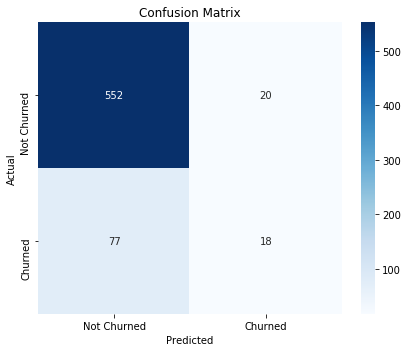


How to read this:
  Top-left  = Correctly predicted NOT churned (True Negatives)
  Top-right = Wrongly predicted churned, but actually didn't (False Positives)
  Bot-left  = Wrongly predicted not churned, but actually did (False Negatives)  ← costly!
  Bot-right = Correctly predicted churned (True Positives)



In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Churned', 'Churned'],
    yticklabels=['Not Churned', 'Churned'],
    ax=ax
)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

print("""
How to read this:
  Top-left  = Correctly predicted NOT churned (True Negatives)
  Top-right = Wrongly predicted churned, but actually didn't (False Positives)
  Bot-left  = Wrongly predicted not churned, but actually did (False Negatives)  ← costly!
  Bot-right = Correctly predicted churned (True Positives)
""")

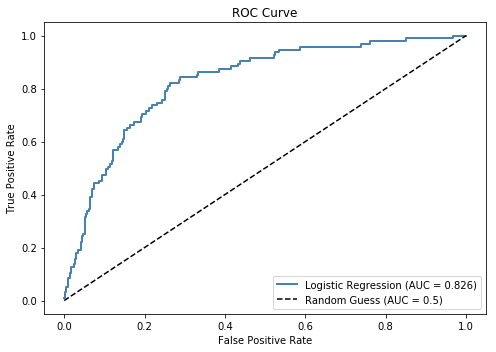

In [19]:
# ROC Curve — shows the trade-off between catching churners and false alarms
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})', color='steelblue', lw=2)
ax.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')  # baseline
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

## Step 7: Feature Importance

Which features have the biggest impact on churn prediction?

In Logistic Regression, larger absolute coefficients = more important features.

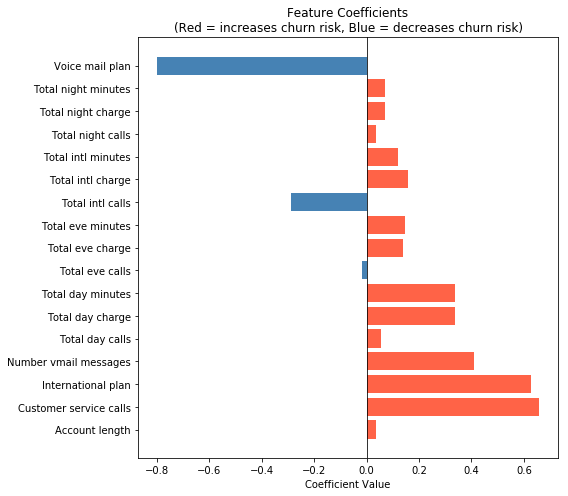

Top 5 features driving churn:
                   Feature  Coefficient
2          Voice mail plan    -0.799340
16  Customer service calls     0.657855
1       International plan     0.626781
3    Number vmail messages     0.410113
6         Total day charge     0.338603


In [20]:
# Extract feature coefficients
feature_importance = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Coefficient': model.coef_[0]
})

# Sort by absolute value so biggest impact features are at the top
feature_importance['Abs_Coef'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coef', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['tomato' if c > 0 else 'steelblue' for c in feature_importance['Coefficient']]
ax.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Coefficients\n(Red = increases churn risk, Blue = decreases churn risk)')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print('Top 5 features driving churn:')
print(feature_importance.sort_values('Abs_Coef', ascending=False).head(5)[['Feature','Coefficient']])

## Summary

| Metric | Value |
|--------|-------|
| Model | Logistic Regression |
| Training rows | ~2666 |
| Test rows | ~667 |
| Accuracy | See output above |
| ROC-AUC | See output above |

### What we did:
1. **Loaded** train and test CSV files
2. **Explored** the data — checked shapes, missing values, churn rate
3. **Preprocessed** — encoded Yes/No columns, dropped low-signal columns, scaled features
4. **Trained** a Logistic Regression model
5. **Evaluated** using accuracy, confusion matrix, classification report, and ROC-AUC
6. **Interpreted** feature importance using model coefficients

### Next steps you could try:
- Try a **Random Forest** or **XGBoost** model for better accuracy
- Handle class imbalance with `class_weight='balanced'` in LogisticRegression
- Do **hyperparameter tuning** using GridSearchCV